# Post 11: How Do Adaptive and Nonequilibrium Enhanced-Sampling Methods Work?

This notebook is the presentation layer for the eleventh tutorial. The reusable metadynamics-style bias, nonequilibrium pulling, Jarzynski/Crooks, and figure logic lives in `src/kups_md_tutorials/`.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.enhanced_sampling import load_enhanced_sampling_summary
from kups_md_tutorials.figures import generate_post11_figures

## Configuration

The smoke and full profiles combine a controlled metadynamics-style adaptive-bias diagnostic with a nonequilibrium pulling ensemble on the same double-well coordinate.

In [3]:
for path in [Path("configs/post-11/smoke.json"), Path("configs/post-11/full.json")]:
    config = json.loads(path.read_text())
    print(path)
    print(json.dumps(config["enhanced_sampling_experiment"], indent=2))

configs/post-11/smoke.json
{
  "temperature": 1.0,
  "domain_min": -2.5,
  "domain_max": 2.5,
  "grid_points": 1201,
  "seed": 2026071411,
  "metadynamics": {
    "deposit_count": 450,
    "hill_height": 0.045,
    "hill_width": 0.14,
    "bias_factor": 8.0,
    "record_every": 10
  },
  "pulling": {
    "path_count": 1200,
    "path_steps": 140,
    "trap_force_constant": 18.0,
    "start_center": -1.1,
    "end_center": 1.1,
    "noise_scale": 0.2
  }
}
configs/post-11/full.json
{
  "temperature": 1.0,
  "domain_min": -2.5,
  "domain_max": 2.5,
  "grid_points": 2001,
  "seed": 2026071411,
  "metadynamics": {
    "deposit_count": 3000,
    "hill_height": 0.03,
    "hill_width": 0.12,
    "bias_factor": 10.0,
    "record_every": 25
  },
  "pulling": {
    "path_count": 20000,
    "path_steps": 260,
    "trap_force_constant": 18.0,
    "start_center": -1.1,
    "end_center": 1.1,
    "noise_scale": 0.2
  }
}


## Committed Full-Profile Diagnostics

The summary records bias filling, basin and barrier visitation, reconstructed barrier error, pulling work dissipation, Jarzynski estimates, Crooks crossing, exponential-weight effective sample sizes, fast/slow steered-trajectory hysteresis, and a compact pair-distance steered-pulling diagnostic with runtime provenance.


In [4]:
summary = load_enhanced_sampling_summary(Path("results/post-11/full/enhanced_sampling_summary.json"))
meta = summary.metadynamics
pull = summary.pulling
hyst = summary.steered_hysteresis
pair = summary.pair_distance_steered
print("metadynamics")
print(f"  bias range: {meta.final_bias_range:.4f}")
print(f"  reconstructed barrier error: {meta.reconstructed_barrier_error:.4f}")
print(f"  left/right/barrier visits: {meta.basin_visit_fraction_left:.3f}, {meta.basin_visit_fraction_right:.3f}, {meta.barrier_visit_fraction:.3f}")
print("pulling")
print(f"  true Delta F: {pull.true_delta_f:.4f}")
print(f"  forward mean work: {pull.forward_mean_work:.4f}")
print(f"  forward Jarzynski: {pull.forward_jarzynski_delta_f:.4f}")
print(f"  reverse Jarzynski: {pull.reverse_jarzynski_delta_f:.4f}")
print(f"  Crooks crossing: {pull.crooks_crossing_delta_f:.4f}")
print(f"  forward ESS fraction: {pull.forward_ess_fraction:.4f}")
print("steered trajectory hysteresis")
print(f"  fast protocol steps: {hyst.fast_path_steps}")
print(f"  slow protocol steps: {hyst.slow_path_steps}")
print(f"  fast hysteresis gap: {hyst.fast_hysteresis_gap:.4f} +/- {hyst.fast_hysteresis_gap_sem:.4f}")
print(f"  slow hysteresis gap: {hyst.slow_hysteresis_gap:.4f} +/- {hyst.slow_hysteresis_gap_sem:.4f}")
print(f"  fast/slow gap ratio: {hyst.hysteresis_gap_ratio:.2f}")
if pair is not None:
    print("pair-distance steered pulling")
    print(f"  target/runtime: {pair.target_device} / {pair.runtime_device}")
    print(f"  production GPU ready: {pair.production_gpu_ready}")
    print(f"  fast/slow gap ratio: {pair.hysteresis_gap_ratio:.2f}")
    print(f"  true Delta F: {pair.true_delta_f:.4f}")
    print(f"  forward/reverse Jarzynski: {pair.forward_jarzynski_delta_f:.4f}, {pair.reverse_jarzynski_delta_f:.4f}")
    print(f"  Jarzynski spread: {pair.jarzynski_spread:.4f}")
    print(f"  slow ESS fractions: {pair.forward_ess_fraction:.4f}, {pair.reverse_ess_fraction:.4f}")


metadynamics
  bias range: 6.5339
  reconstructed barrier error: 0.0922
  left/right/barrier visits: 0.360, 0.362, 0.135
pulling
  true Delta F: -0.0000
  forward mean work: 0.1699
  forward Jarzynski: 0.0011
  reverse Jarzynski: -0.0090
  Crooks crossing: -0.0007
  forward ESS fraction: 0.7159
steered trajectory hysteresis
  fast protocol steps: 65
  slow protocol steps: 520
  fast hysteresis gap: 33.7415 +/- 0.2534
  slow hysteresis gap: 5.5457 +/- 0.1116
  fast/slow gap ratio: 6.08
pair-distance steered pulling
  target/runtime: cuda_or_cpu_fallback / jax:cpu;devices:cpu
  production GPU ready: False
  fast/slow gap ratio: 5.43
  true Delta F: 0.6065
  forward/reverse Jarzynski: 1.3534, -0.1371
  Jarzynski spread: 1.4905
  slow ESS fractions: 0.3697, 0.3913


## Figure Regeneration

The figure is regenerated from committed compact output files, not from notebook-local simulation code.

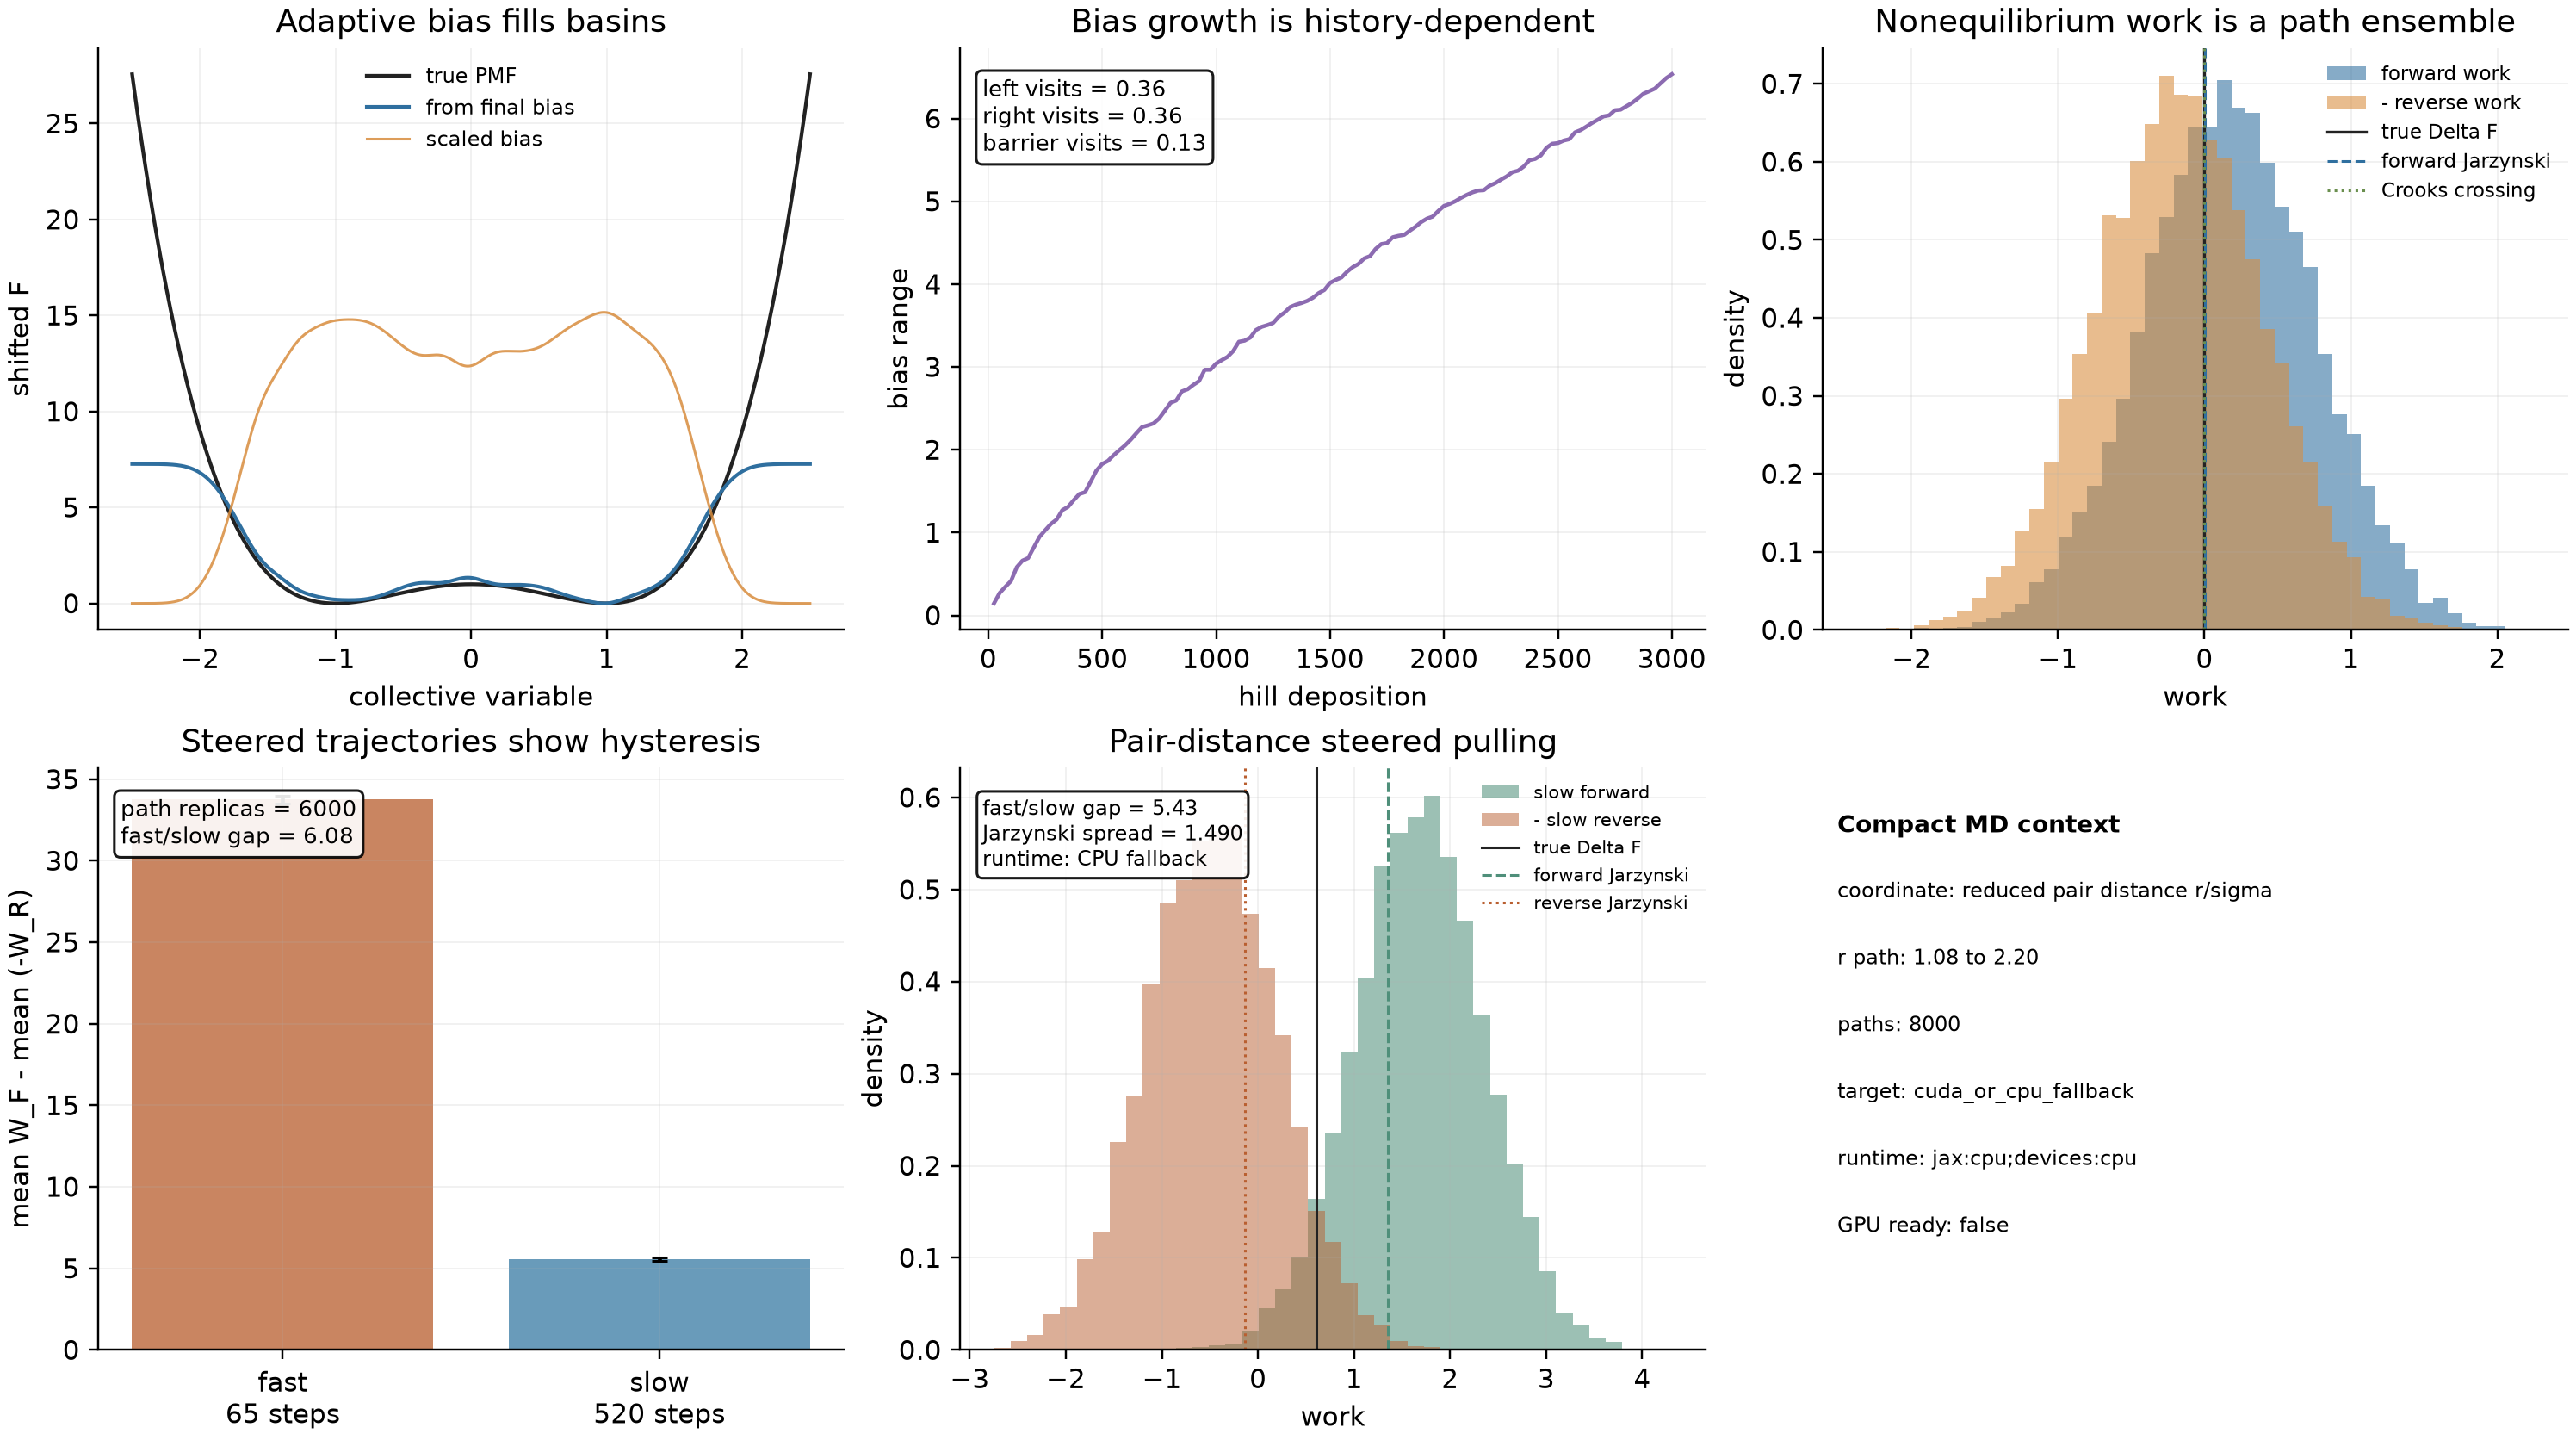

In [5]:
generate_post11_figures(
    result_dir=Path("results/post-11/full"),
    figure_dir=Path("figures/post-11"),
    snapshot_dir=Path("snapshots/post-11"),
    name="enhanced_sampling_diagnostics_full",
)
display(Image(filename="figures/post-11/enhanced_sampling_diagnostics_full.png"))